# Phase 1 — Proof of Concept: Multimodal Land Cover Segmentation


## What This Notebook Does

In this notebook, I demonstrate that all the components I plan to combine — satellite image loading,
mask preprocessing, SegFormer fine-tuning, BERT caption encoding, and cross-attention fusion — work
end to end. Phase 1 is about showing feasibility, not final results.

### Research Question

> *"Does conditioning a segmentation transformer on AI-generated scene descriptions improve land cover
segmentation accuracy, and which vision-language model produces the most useful descriptions?"*

### Important NOTE: Caption Column Selection

The dataset includes five caption columns, but I only use **`vision_gemma3-4b`** and
**`vision_qwen3-vl-8b`** in my experiments. The other three columns (`hybrid_gemma3-4b`,
`hybrid_qwen3-vl-8b`, `text_qwen3-4b`) were generated using the actual ground truth land cover
percentages as inputs, so they encode label information directly. Using them would mean the model
learns to extract numbers from sentences rather than genuinely learning visual-textual grounding —
which would make the comparison with the image-only baseline meaningless.


Note to remember:
* Tree -> Ağaçlık alan | renk: koyu yeşil | RGB: (0, 100, 0)
* Shrub -> Çalılık alan | renk: pembe | RGB: (255, 182, 193)
* Grass -> Ot/çayır alanı | renk: açık yeşil | RGB: (154, 205, 50)
* Crop -> Tarım alanı | renk: altın sarısı | RGB: (255, 215, 0)
* Built-up -> Yapılaşmış alan | renk: kahverengi | RGB: (139, 69, 19)
* Barren -> Çıplak arazi | renk: açık gri | RGB: (211, 211, 211)
* Water -> Su yüzeyi | renk: mavi | RGB: (0, 0, 255)

## 0. Setup


In [1]:
# I install all required packages here so the notebook works out of the box on Colab or Kaggle.
# On my local M1 machine I run this once in a virtual environment; on Colab this runs fresh each session.
# !pip install -q torch torchvision transformers accelerate evaluate
# !pip install -q pillow matplotlib seaborn scikit-learn pandas numpy pyyaml


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    SegformerForSemanticSegmentation,
    SegformerImageProcessor,
    BertModel,
    BertTokenizer,
)

warnings.filterwarnings('ignore')

print('All imports successful.')
print(f'PyTorch version: {torch.__version__}')


/Users/fatmaoztel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All imports successful.
PyTorch version: 2.8.0


In [3]:
import os
import platform

# Store all hyperparameters
CONFIG = {
    'image_size':    256,    # Resize to 256x256 — fits free-tier Colab GPU memory comfortably
    'batch_size':    4,      # Small batch to avoid OOM; I'll increase to 8 in Phase 2
    'num_epochs':    3,      # Phase 1 PoC: just enough to confirm the loss decreases
    'learning_rate': 6e-5,   # Standard starting LR for SegFormer fine-tuning (from paper)
    'subset_size':   200,    # Train on 200 samples for Phase 1 speed; full 10k in Phase 2
    'val_subset':    50,     # Validate on 50 samples for Phase 1
    'num_classes':   7,
    'seed':          42,
    'model_name':    'nvidia/mit-b0',
    'text_model':    'bert-base-uncased',
}

# NEED FOR USING CPU on MAC
def get_device():
    """
    Important NOTE: MPS (Apple Silicon GPU) causes a hard crash during SegFormer's
    backward pass — the autograd C++ engine calls .view() on a non-contiguous tensor,
    which MPS cannot handle. This is a known PyTorch/MPS bug that the PYTORCH_ENABLE_MPS_FALLBACK
    env var cannot fix because the error originates in the autograd engine itself, not in an
    MPS kernel. Per AGENT.md guidance, I fall back to CPU on macOS for local development.
    Full training will run on Colab (CUDA) where this issue does not exist.
    CPU on M1 is slow but correct — 200 samples x 3 epochs is manageable locally.
    """
    if torch.cuda.is_available():
        return torch.device('cuda')
    elif platform.system() == 'Darwin':
        # Force CPU on macOS — MPS is incompatible with SegFormer backprop
        return torch.device('cpu')
    else:
        return torch.device('cpu')


device = get_device()
print(f'Platform : {platform.system()}')
print(f'Device   : {device}')
if platform.system() == 'Darwin':
    print('NOTE: Running on CPU (MPS disabled due to SegFormer backprop incompatibility).')
    print('      Upload to Colab/Kaggle for GPU-accelerated full training.')

# For reproducibility
torch.manual_seed(CONFIG['seed'])
np.random.seed(CONFIG['seed'])


Platform : Darwin
Device   : cpu
NOTE: Running on CPU (MPS disabled due to SegFormer backprop incompatibility).
      Upload to Colab/Kaggle for GPU-accelerated full training.


In [4]:
# Define the class-color mapping from the project specification.
CLASS_INFO = {
    0: {'name': 'Tree',     'color': (0,   100, 0)},
    1: {'name': 'Shrub',    'color': (255, 182, 193)},
    2: {'name': 'Grass',    'color': (154, 205, 50)},
    3: {'name': 'Crop',     'color': (255, 215, 0)},
    4: {'name': 'Built-up', 'color': (139, 69,  19)},
    5: {'name': 'Barren',   'color': (211, 211, 211)},
    6: {'name': 'Water',    'color': (0,   0,   255)},
}

# Derived lookup structures — generated once, used throughout
CLASS_COLORS  = {info['color']: idx  for idx, info in CLASS_INFO.items()}
CLASS_NAMES   = [CLASS_INFO[i]['name'] for i in range(len(CLASS_INFO))]
CLASS_PALETTE = np.array([CLASS_INFO[i]['color'] for i in range(len(CLASS_INFO))], dtype=np.uint8)
id2label      = {idx: info['name']   for idx, info in CLASS_INFO.items()}
label2id      = {info['name']: idx   for idx, info in CLASS_INFO.items()}

print('Land cover classes:')
for idx, info in CLASS_INFO.items():
    print(f'  [{idx}] {info["name"]:10s}  RGB{info["color"]}')


Land cover classes:
  [0] Tree        RGB(0, 100, 0)
  [1] Shrub       RGB(255, 182, 193)
  [2] Grass       RGB(154, 205, 50)
  [3] Crop        RGB(255, 215, 0)
  [4] Built-up    RGB(139, 69, 19)
  [5] Barren      RGB(211, 211, 211)
  [6] Water       RGB(0, 0, 255)


## 1. Dataset Loading and Exploration

I start by loading the CSV file that maps each sample to its caption columns and the pre-defined
train/validation split. The actual images and masks live in the `data/images/` and `data/masks/`
folders, referenced by filename.

Important NOTE: I check for the `split` column in the CSV before creating any DataLoader.
Using a random split on satellite imagery is risky because adjacent tiles may overlap spatially,
causing data leakage between train and validation sets. The pre-defined split is the safe choice.


In [5]:
# Auto-detect the data directory
for _candidate in ['data', '../data']:
    if os.path.exists(os.path.join(_candidate, 'captions.csv')):
        DATA_DIR = _candidate
        break
else:
    DATA_DIR = 'data'

IMAGES_DIR   = os.path.join(DATA_DIR, 'images')
MASKS_DIR    = os.path.join(DATA_DIR, 'masks')
CAPTIONS_CSV = os.path.join(DATA_DIR, 'captions.csv')

print(f'Data directory: "{os.path.abspath(DATA_DIR)}"')


Data directory: "/Users/fatmaoztel/PycharmProjects/multimodal-landcover-segmentation/data"


In [6]:
# Check file name and csv is compatible
data_available = os.path.exists(CAPTIONS_CSV)
captions_df = pd.read_csv(CAPTIONS_CSV)

FAIR_CAPTION_COLS = ['vision_gemma3-4b', 'vision_qwen3-vl-8b']
FN_COL = None

def normalise_filename(fn_raw):
    """Ensure the filename ends with .png — works for any number of digits."""
    fn = str(fn_raw).strip()
    return fn if fn.endswith('.png') else fn + '.png'

if data_available:
    for candidate in ['filename', 'image_id', 'image_name', 'file_name', 'id', 'name']:
        if candidate in captions_df.columns:
            FN_COL = candidate
            break
    if FN_COL is None:
        FN_COL = captions_df.columns[0]

    sample_fn_norm = normalise_filename(captions_df.iloc[0][FN_COL])
    img_path  = os.path.join(IMAGES_DIR, sample_fn_norm)
    mask_path = os.path.join(MASKS_DIR,  sample_fn_norm)

    print(f'Filename column : "{FN_COL}"')
    print(f'Sample filename : "{sample_fn_norm}"')
    print(f'Image exists    : {os.path.exists(img_path)}')
    print(f'Mask  exists    : {os.path.exists(mask_path)}')


Filename column : "filename"
Sample filename : "0073.png"
Image exists    : True
Mask  exists    : True


In [7]:
# I only display captions from the two fair (vision-only) columns.

if data_available and FN_COL is not None:
    row = captions_df.iloc[0]
    print(f'Sample: {row[FN_COL]}\n')
    for col in FAIR_CAPTION_COLS:
        if col in captions_df.columns:
            print(f'[{col}]:')
            print(f'  {row[col]}')
            print()

Sample: 0073.png

[vision_gemma3-4b]:
  This image depicts a rugged, arid landscape characterized by extensive rocky terrain and deeply incised gullies, likely indicative of a desert or semi-arid environment with minimal vegetation cover. The dominant land use appears to be bare rock and soil, shaped by erosion and geological processes.

[vision_qwen3-vl-8b]:
  This remote sensing image shows a rugged, arid landscape dominated by exposed bedrock and sparse vegetation, with a prominent linear feature—likely a dry riverbed or fault line—cutting through the terrain, indicating a geologically active or erosion-prone region.



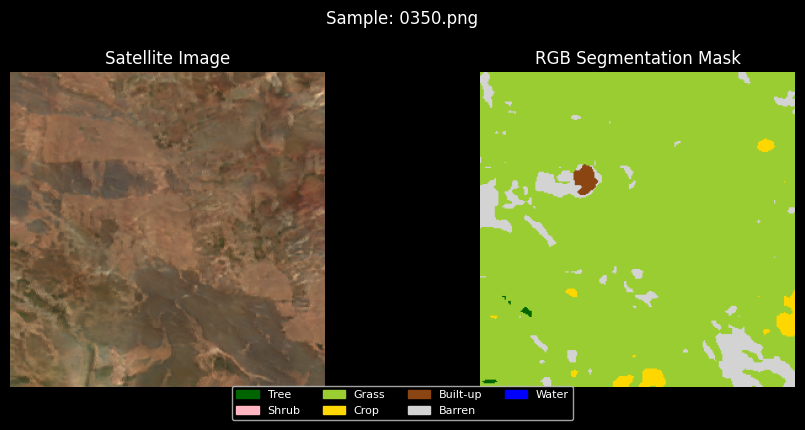

In [8]:
os.makedirs('results/figures', exist_ok=True)


def show_image_and_mask(image_path, mask_path, title='Sample'):
    """Display a satellite image alongside its RGB segmentation mask."""
    img  = np.array(Image.open(image_path).convert('RGB'))
    mask = np.array(Image.open(mask_path).convert('RGB'))

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img);  axes[0].set_title('Satellite Image');       axes[0].axis('off')
    axes[1].imshow(mask); axes[1].set_title('RGB Segmentation Mask'); axes[1].axis('off')

    patches = [
        mpatches.Patch(color=np.array(info['color']) / 255, label=info['name']) # gets the class RGB color, like (0, 100, 0)
        # creates a colored square patch
        for info in CLASS_INFO.values()
    ]
    fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
               bbox_to_anchor=(0.5, -0.06))
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.savefig('results/figures/sample_image_mask.png', dpi=300, bbox_inches='tight')
    plt.show()


if data_available and FN_COL is not None:
    sample_fn_norm = normalise_filename(captions_df.iloc[10][FN_COL])
    img_path  = os.path.join(IMAGES_DIR, sample_fn_norm)
    mask_path = os.path.join(MASKS_DIR,  sample_fn_norm)

    if os.path.exists(img_path) and os.path.exists(mask_path):
        show_image_and_mask(img_path, mask_path, title=f'Sample: {sample_fn_norm}')
    else:
        print(f'Image or mask not found!!!')


## 2. Mask Preprocessing — RGB to Class Index

The segmentation masks are stored as RGB images, but SegFormer (and PyTorch's cross-entropy loss)
expects a single-channel integer mask where each pixel value is a class index in [0, 6].
I implement a vectorized conversion using NumPy --> pixel-by-pixel

I also implement the reverse function (`class_mask_to_rgb`) for visualization: it converts
predicted integer masks back to colored images so we can visually compare predictions to
ground truth.


In [9]:
def rgb_mask_to_class(mask_rgb: np.ndarray) -> np.ndarray:
    """
    Convert an RGB segmentation mask to a single-channel class index mask.

    I use vectorized NumPy comparisons (one pass per class) instead of a pixel loop
    because it is so fast!
    Pixels that do not match any known color are left as 0 (Tree) BUT in practice
    this should not happen with the provided dataset.

    NOTE:
    Under normal dataset conditions, every pixel should be valid, but if not, this fallback could hide errors.
    The masks were presumably generated programmatically, not hand-painted
    Segmentation masks usually use an exact palette
    PNG mask files should preserve exact RGB values without compression artifacts

    Args:
        mask_rgb: numpy array of shape (H, W, 3), dtype uint8
    Returns:
        class_mask: numpy array of shape (H, W), dtype int64
    """
    h, w, _ = mask_rgb.shape
    class_mask = np.zeros((h, w), dtype=np.int64)
    for color, class_idx in CLASS_COLORS.items():
        match = np.all(mask_rgb == np.array(color, dtype=np.uint8), axis=-1)
        class_mask[match] = class_idx
    return class_mask


def class_mask_to_rgb(class_mask: np.ndarray) -> np.ndarray:
    """
    Convert a class index mask back to an RGB image for visualization.
    """
    h, w = class_mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for class_idx in range(len(CLASS_INFO)):
        rgb[class_mask == class_idx] = CLASS_INFO[class_idx]['color']
    return rgb


# Test it
test_mask_rgb = np.array(
        Image.open(mask_path).convert('RGB').resize(
            (CONFIG['image_size'], CONFIG['image_size']), Image.NEAREST
        )
    )


test_class_mask = rgb_mask_to_class(test_mask_rgb)

print(f'Input RGB mask shape:   {test_mask_rgb.shape}   dtype: {test_mask_rgb.dtype}')
print(f'Output class mask shape: {test_class_mask.shape}  dtype: {test_class_mask.dtype}')
print(f'Unique class indices found: {np.unique(test_class_mask).tolist()}')
print(f'Corresponding class names:  {[CLASS_NAMES[i] for i in np.unique(test_class_mask)]}')


Input RGB mask shape:   (256, 256, 3)   dtype: uint8
Output class mask shape: (256, 256)  dtype: int64
Unique class indices found: [0, 2, 3, 4, 5]
Corresponding class names:  ['Tree', 'Grass', 'Crop', 'Built-up', 'Barren']


### The class index mask

A class index mask is a segmentation mask where each pixel stores a class number instead of an RGB color.

Why it is used:

* segmentation models like SegFormer do not train on RGB color masks
* the loss function expects each pixel’s ground-truth label as a class ID
* PyTorch cross-entropy for segmentation needs shape (H, W) with integer labels, not (H, W, 3) RGB values

So the RGB mask is just a human-readable storage/visualization format, and the class index mask is the machine-readable training format.

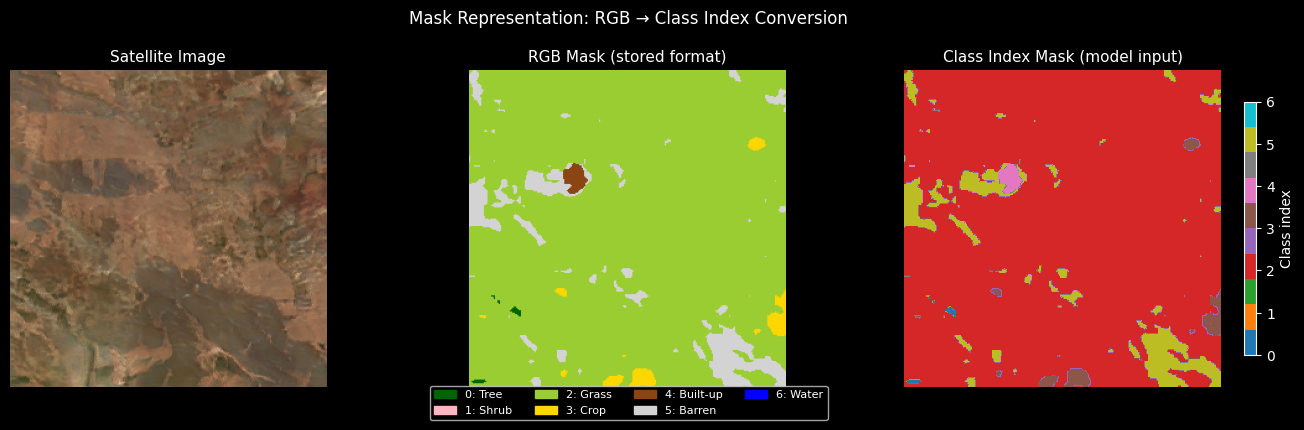

In [10]:
# I visualize all three representations side by side: the original image, the stored RGB mask,
# and the class index mask I actually feed into the model.
# LETS check it as well
# Use it the test_class_mask to show it

display_img = np.array(Image.open(img_path).convert('RGB').resize(
        (CONFIG['image_size'], CONFIG['image_size'])
    ))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(display_img)
axes[0].set_title('Satellite Image', fontsize=11)
axes[0].axis('off')

axes[1].imshow(test_mask_rgb)
axes[1].set_title('RGB Mask (stored format)', fontsize=11)
axes[1].axis('off')

im = axes[2].imshow(test_class_mask, cmap='tab10', vmin=0, vmax=CONFIG['num_classes'] - 1)
axes[2].set_title('Class Index Mask (model input)', fontsize=11)
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], shrink=0.8, label='Class index')

# FOR LEGEND
patches = [
    mpatches.Patch(color=np.array(CLASS_INFO[i]['color']) / 255,
                   label=f"{i}: {CLASS_INFO[i]['name']}")
    for i in range(CONFIG['num_classes'])
]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=8,
           bbox_to_anchor=(0.5, -0.06))

plt.suptitle('Mask Representation: RGB → Class Index Conversion', fontsize=12)
plt.tight_layout()
plt.savefig('results/figures/mask_conversion.png', dpi=300, bbox_inches='tight')
plt.show()


## 3. Custom PyTorch Dataset and DataLoaders

I implement a `LandCoverDataset` class that handles image loading, mask conversion, and caption
fetching together. The `caption_col` argument makes it easy to switch between the two fair caption
sources.

For Phase 1, I take a 200-sample subset of the training split to keep training fast. The goal here
is just to confirm the pipeline works, not to converge.


In [11]:
class LandCoverDataset(Dataset):
    """
    Designed this dataset class to handle the three-way correspondence between
    satellite images, segmentation masks, and (optionally) text captions.
    Setting caption_col=None gives the image-only baseline DataLoader;
    setting it to a column name gives the fused model DataLoader.
    """

    def __init__(self, df, images_dir, masks_dir, processor,
                 caption_col=None, image_size=256):
        """
        Args:
            df:          DataFrame subset (already filtered by split)
            images_dir:  path to folder containing satellite images (e.g. data/images/)
            masks_dir:   path to folder containing RGB mask images  (e.g. data/masks/)
            processor:   SegformerImageProcessor — handles resizing and normalization
            caption_col: which caption column to load (None = image-only mode)
            image_size:  target image height and width in pixels
        """
        self.df          = df.reset_index(drop=True)
        self.images_dir  = images_dir
        self.masks_dir   = masks_dir
        self.processor   = processor
        self.caption_col = caption_col
        self.image_size  = image_size

        # Identify the filename column
        self.fn_col = df.columns[0]  # fallback
        for candidate in ['filename', 'image_id', 'image_name', 'file_name', 'id', 'name']:
            if candidate in df.columns:
                self.fn_col = candidate
                break

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # normalise_filename
        filename = normalise_filename(row[self.fn_col])

        # Load and preprocess satellite image
        image = Image.open(os.path.join(self.images_dir, filename)).convert('RGB')
        processed    = self.processor(
            images=image,
            size={'height': self.image_size, 'width': self.image_size},
            return_tensors='pt'
        )
        pixel_values = processed['pixel_values'].squeeze(0)  # (3, H, W)

        # Load, resize, and convert mask to class indices
        mask_rgb = np.array(
            Image.open(os.path.join(self.masks_dir, filename))
            .convert('RGB')
            .resize((self.image_size, self.image_size), Image.NEAREST)
        )
        label = torch.tensor(rgb_mask_to_class(mask_rgb), dtype=torch.long)  # (H, W)

        item = {'pixel_values': pixel_values, 'labels': label, 'filename': filename}

        # Optionally include a caption string for the fused model experiments
        if self.caption_col and self.caption_col in self.df.columns:
            item['caption'] = str(row[self.caption_col])

        return item

In [12]:
from sklearn.model_selection import train_test_split
import platform

processor = SegformerImageProcessor.from_pretrained(
    CONFIG['model_name'],
    do_reduce_labels=False
)

# num_workers=0 on macOS
NUM_WORKERS = 0 if platform.system() == 'Darwin' else 2

if data_available:
    # Important NOTE: The 'split' column in this CSV contains only 'synth' for all 10,000
    # rows — it does not encode a train/val/test split. I ignore it entirely and create
    # a reproducible 80/10/10 split in memory using a fixed seed.
    # I use sklearn's train_test_split twice:
    #   Step 1 — split full set into 80% train and 20% temp
    #   Step 2 — split temp into 50% val and 50% test  →  10% val, 10% test overall
    all_indices = captions_df.index.tolist()

    train_idx, temp_idx = train_test_split(
        all_indices, test_size=0.20, random_state=CONFIG['seed']
    )
    val_idx, test_idx = train_test_split(
        temp_idx,   test_size=0.50, random_state=CONFIG['seed']
    )

    train_df_full = captions_df.loc[train_idx]
    val_df_full   = captions_df.loc[val_idx]
    test_df_full  = captions_df.loc[test_idx]

    print(f'Split (seed={CONFIG["seed"]}):')
    print(f'  Train : {len(train_df_full):,} samples  ({len(train_df_full)/len(captions_df)*100:.0f}%)')
    print(f'  Val   : {len(val_df_full):,} samples  ({len(val_df_full)/len(captions_df)*100:.0f}%)')
    print(f'  Test  : {len(test_df_full):,} samples  ({len(test_df_full)/len(captions_df)*100:.0f}%)')

    # Phase 1 subset
    train_df = train_df_full.head(CONFIG['subset_size'])
    val_df   = val_df_full.head(CONFIG['val_subset'])
    test_df  = test_df_full.head(CONFIG['val_subset'])

    print(f'\nPhase 1 subsets used:')
    print(f'  Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}')

    train_dataset = LandCoverDataset(train_df, IMAGES_DIR, MASKS_DIR, processor,
                                     image_size=CONFIG['image_size'])
    val_dataset   = LandCoverDataset(val_df,   IMAGES_DIR, MASKS_DIR, processor,
                                     image_size=CONFIG['image_size'])
    test_dataset  = LandCoverDataset(test_df,  IMAGES_DIR, MASKS_DIR, processor,
                                     image_size=CONFIG['image_size'])

    train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                              shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
    val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)
    test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'],
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)

    print(f'\nTrain batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
else:
    train_loader = val_loader = test_loader = None
    train_dataset = val_dataset = test_dataset = None
    print('Dataset not available — skipping DataLoader creation.')


Split (seed=42):
  Train : 8,000 samples  (80%)
  Val   : 1,000 samples  (10%)
  Test  : 1,000 samples  (10%)

Phase 1 subsets used:
  Train : 200 | Val : 50 | Test : 50

Train batches: 50 | Val batches: 13 | Test batches: 13


## 4. SegFormer Baseline — Fine-Tuning

I fine-tune `nvidia/mit-b0` (SegFormer's smallest encoder variant, ~3.7M parameters) on the
7-class land cover task. I chose MiT-B0 because it is fast enough to train on free-tier
Colab GPUs and previous work on remote sensing segmentation shows it achieves competitive results
even at this scale. In the following phases, I can try another models if resources allow.

For Phase 1, I run only 3 epochs on 200 samples. The loss should decrease, which confirms the
training pipeline is correct. I'm not expecting high mIoU at this stage.

Important NOTE: SegFormer's decoder outputs logits at 1/4 the input resolution
(64×64 for 256×256 inputs). ---> If you give SegFormer a 256 x 256 image,
the model does not directly output a 256 x 256 prediction map. It outputs a
smaller prediction map, here 64 x 64.


In [13]:
# Classification head with a 7-classes
segformer = SegformerForSemanticSegmentation.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_classes'],
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
).to(device)

total_params     = sum(p.numel() for p in segformer.parameters())
trainable_params = sum(p.numel() for p in segformer.parameters() if p.requires_grad)

print(f'SegFormer MiT-B0 loaded successfully.')
print(f'  Total parameters:     {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,}')
print(f'  Model device:         {next(segformer.parameters()).device}')


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


SegFormer MiT-B0 loaded successfully.
  Total parameters:     3,715,943
  Trainable parameters: 3,715,943
  Model device:         cpu


In [14]:
def compute_miou(preds: torch.Tensor, targets: torch.Tensor, num_classes: int) -> float:
    """
    Compute mean Intersection over Union across all classes.

    This function measures how well the predicted segmentation overlaps with the true segmentation,
    averaged across classes.

    I skip classes absent from both prediction and target to avoid
    inflating mIoU on easy images. This matches the standard evaluation
    protocol for semantic segmentation benchmarks.
    """
    preds_np   = preds.cpu().numpy().flatten()
    targets_np = targets.cpu().numpy().flatten()
    ious = []
    for cls in range(num_classes):
        pred_c   = (preds_np == cls)
        target_c = (targets_np == cls)
        union = (pred_c | target_c).sum()
        if union > 0:
            ious.append((pred_c & target_c).sum() / union)
    return float(np.mean(ious)) if ious else 0.0


def train_one_epoch(model, loader, optimizer, device, num_classes):
    model.train()
    total_loss = 0.0
    for batch in loader:
        pixel_values = batch['pixel_values'].to(device)
        labels       = batch['labels'].to(device)

        # SegFormer computes cross-entropy loss internally when labels are provided
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device, num_classes):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch['pixel_values'].to(device)
            labels       = batch['labels'].to(device)

            logits = model(pixel_values=pixel_values).logits  # (B, C, H/4, W/4)

            # Upsample logits to full label resolution before argmax
            upsampled = F.interpolate(logits, size=labels.shape[-2:],
                                      mode='bilinear', align_corners=False)
            preds = upsampled.argmax(dim=1)  # (B, H, W)

            all_preds.append(preds)
            all_targets.append(labels)

    return compute_miou(
        torch.cat(all_preds, dim=0),
        torch.cat(all_targets, dim=0),
        num_classes
    )


In [15]:
# TRAINNNN!
optimizer = optim.AdamW(segformer.parameters(), lr=CONFIG['learning_rate'])

train_losses, val_mious = [], []

print(f'Training SegFormer baseline: {CONFIG["num_epochs"]} epochs on '
      f'{CONFIG["subset_size"]} samples (Phase 1 subset)')
print('-' * 60)

for epoch in range(1, CONFIG['num_epochs'] + 1):
    train_loss = train_one_epoch(
        segformer, train_loader, optimizer, device, CONFIG['num_classes']
    )
    val_miou = evaluate(segformer, val_loader, device, CONFIG['num_classes'])

    train_losses.append(train_loss)
    val_mious.append(val_miou)

    print(f'Epoch {epoch}/{CONFIG["num_epochs"]}  '
          f'Loss: {train_loss:.4f}  |  Val mIoU: {val_miou:.4f}')

print('-' * 60)
print('Training complete.')


Training SegFormer baseline: 3 epochs on 200 samples (Phase 1 subset)
------------------------------------------------------------
Epoch 1/3  Loss: 1.5867  |  Val mIoU: 0.2452
Epoch 2/3  Loss: 1.1216  |  Val mIoU: 0.3132
Epoch 3/3  Loss: 0.9780  |  Val mIoU: 0.3973
------------------------------------------------------------
Training complete.


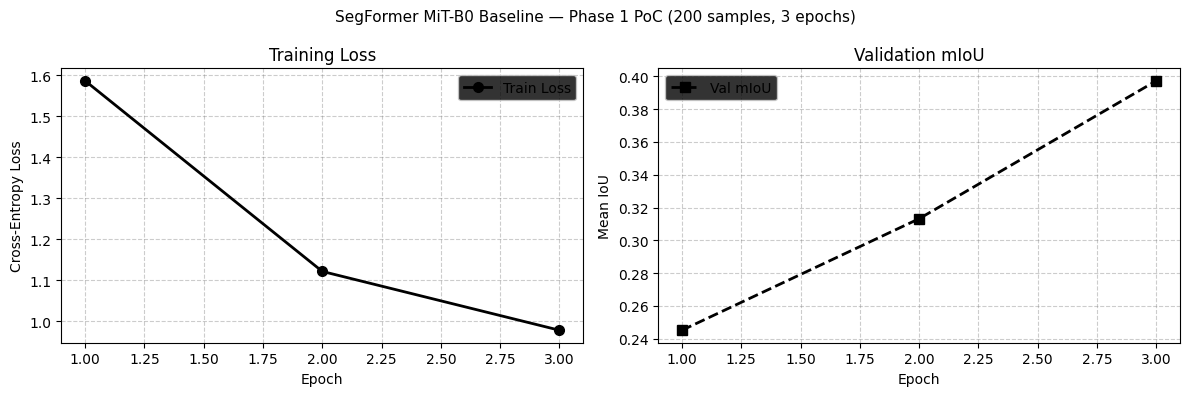

Final train loss: 0.9780
Final val mIoU:   0.3973


In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), facecolor='white')

epochs = list(range(1, len(train_losses) + 1))

for ax in (ax1, ax2):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')

ax1.plot(epochs, train_losses, 'o-',  color='black', lw=2, ms=7, label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss')
ax1.legend(labelcolor='black')
ax1.grid(True, linestyle='--', alpha=0.4, color='gray')

ax2.plot(epochs, val_mious, 's--', color='black', lw=2, ms=7, label='Val mIoU')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Mean IoU')
ax2.set_title('Validation mIoU')
ax2.legend(labelcolor='black')
ax2.grid(True, linestyle='--', alpha=0.4, color='gray')

fig.suptitle(
    f'SegFormer MiT-B0 Baseline — Phase 1 PoC '
    f'({CONFIG["subset_size"]} samples, {CONFIG["num_epochs"]} epochs)',
    fontsize=11, color='black'
)
plt.tight_layout()
plt.savefig('results/figures/phase1_training_curves.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

print(f'Final train loss: {train_losses[-1]:.4f}')
print(f'Final val mIoU:   {val_mious[-1]:.4f}')


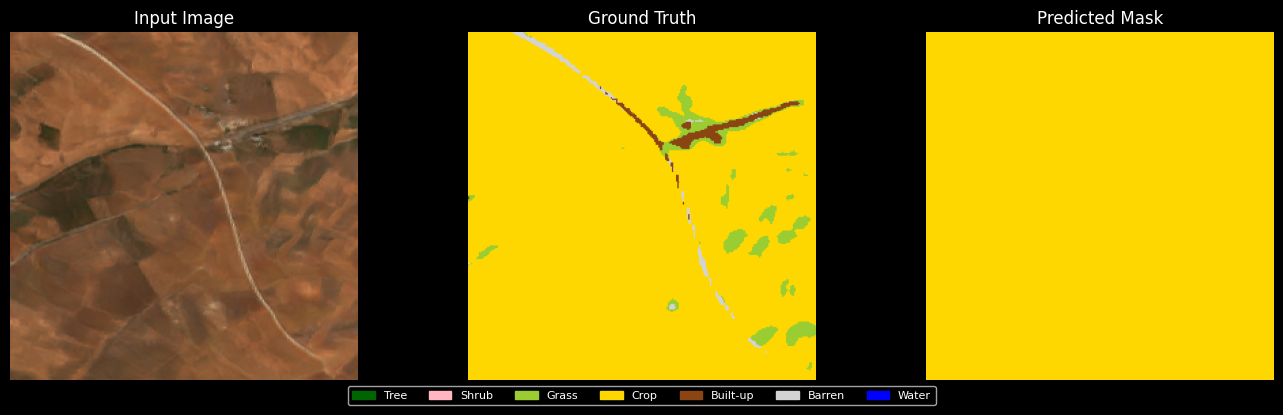

In [17]:
def visualize_prediction(model, dataset, idx, device, save_path=None):
    """
    Show the input image, ground truth mask, and predicted mask side by side.
    """
    model.eval()
    sample = dataset[idx]

    pixel_values = sample['pixel_values'].unsqueeze(0).to(device)
    label        = sample['labels']  # (H, W), int64

    with torch.no_grad():
        logits    = model(pixel_values=pixel_values).logits
        upsampled = F.interpolate(logits, size=label.shape, # We need to that bc it does not do internally
                                  mode='bilinear', align_corners=False)
        pred = upsampled.argmax(dim=1).squeeze(0).cpu()  # (H, W)

    gt_rgb   = class_mask_to_rgb(label.numpy())
    pred_rgb = class_mask_to_rgb(pred.numpy())

    # Recover original image from normalised tensor (ImageNet mean/std)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_np = ((sample['pixel_values'].cpu() * std + mean) * 255)\
             .permute(1, 2, 0).numpy().clip(0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img_np);   axes[0].set_title('Input Image');    axes[0].axis('off')
    axes[1].imshow(gt_rgb);   axes[1].set_title('Ground Truth');   axes[1].axis('off')
    axes[2].imshow(pred_rgb); axes[2].set_title('Predicted Mask'); axes[2].axis('off')

    patches = [
        mpatches.Patch(color=np.array(CLASS_INFO[i]['color']) / 255,
                       label=CLASS_INFO[i]['name'])
        for i in range(CONFIG['num_classes'])
    ]
    fig.legend(handles=patches, loc='lower center', ncol=7, fontsize=8,
               bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# RUN
visualize_prediction(segformer, val_dataset, idx=0, device=device,
                         save_path='results/figures/phase1_prediction.png')


## 5. BERT Caption Encoding

I use `bert-base-uncased` as the text encoder because it produces strong contextual token
embeddings that capture both local word semantics and global sentence context. For the cross-
attention fusion module, I need the **full sequence of token embeddings** (not just the CLS token)
so that image features can attend to specific phrases in the description. For example, the phrase
"dense forest" should produce high attention weights over the green-pixel regions.

IMPORTANT NOTE:

BERT has **110M parameters** vs SegFormer's **3.7M**. Fine-tuning both simultaneously on a small dataset
causes instability and overfitting. Frozen BERT still produces high-quality embeddings — it was pretrained
on billions of sentences and already understands language well.

We can unfreeze it in following phase of the project but let's see.

In [18]:
tokenizer    = BertTokenizer.from_pretrained(CONFIG['text_model'])
text_encoder = BertModel.from_pretrained(CONFIG['text_model'])

for param in text_encoder.parameters():
    param.requires_grad = False

text_encoder = text_encoder.to(device)
text_encoder.eval()

bert_total = sum(p.numel() for p in text_encoder.parameters())
print(f'BERT loaded: {bert_total:,} total parameters (all frozen).')


BERT loaded: 109,482,240 total parameters (all frozen).


In [19]:
row = captions_df.iloc[0]
sample_captions = {
        col: str(row[col]) for col in FAIR_CAPTION_COLS if col in captions_df.columns
    }

all_embeddings = {}

for col, caption in sample_captions.items():
    tokens = tokenizer(
        caption,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=128
    )
    tokens = {k: v.to(device) for k, v in tokens.items()}

    with torch.no_grad():
        outputs = text_encoder(**tokens)

    # last_hidden_state shape: (1, seq_len, 768) — all token embeddings
    # pooler_output shape:     (1, 768)          — CLS token after a linear layer
    all_embeddings[col] = outputs.last_hidden_state.squeeze(0).cpu()

    print(f'[{col}]')
    print(f'  Caption (first 100 chars): {caption[:100]}...')
    print(f'  Token count:               {tokens["input_ids"].shape[1]}')
    print(f'  Full sequence shape:       {outputs.last_hidden_state.shape}  (batch, seq_len, hidden)')
    print(f'  CLS pooler output shape:   {outputs.pooler_output.shape}  (batch, hidden)')
    print(f'  CLS embedding L2 norm:     {outputs.pooler_output.norm().item():.4f}')
    print()


[vision_gemma3-4b]
  Caption (first 100 chars): This image depicts a rugged, arid landscape characterized by extensive rocky terrain and deeply inci...
  Token count:               57
  Full sequence shape:       torch.Size([1, 57, 768])  (batch, seq_len, hidden)
  CLS pooler output shape:   torch.Size([1, 768])  (batch, hidden)
  CLS embedding L2 norm:     18.7109

[vision_qwen3-vl-8b]
  Caption (first 100 chars): This remote sensing image shows a rugged, arid landscape dominated by exposed bedrock and sparse veg...
  Token count:               51
  Full sequence shape:       torch.Size([1, 51, 768])  (batch, seq_len, hidden)
  CLS pooler output shape:   torch.Size([1, 768])  (batch, hidden)
  CLS embedding L2 norm:     18.2716



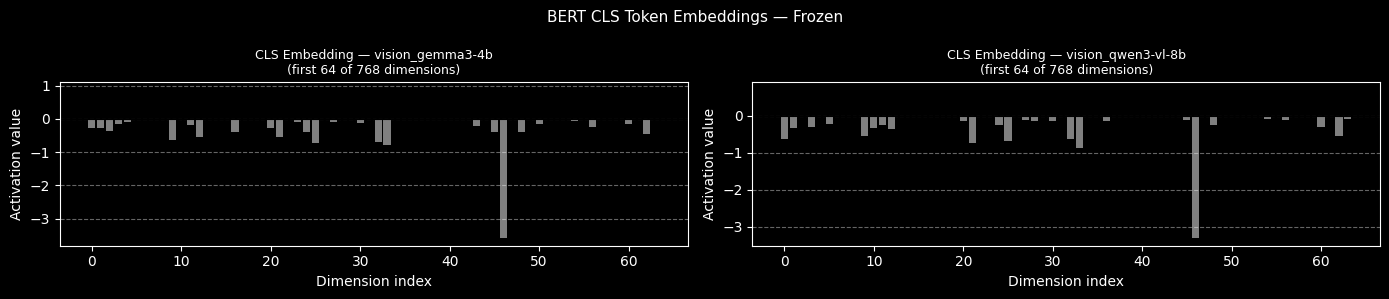

In [20]:
# I visualize the first 64 dimensions of the CLS token embedding for each caption source.
# Even without any fine-tuning, the embeddings for the two caption styles differ noticeably,
# which suggests BERT encodes them differently — interesting to investigate in Phase 2.

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

for ax, (col, emb) in zip(axes, all_embeddings.items()):
    cls_dims = emb[0, :64].numpy()  # CLS token (index 0), first 64 dimensions
    colors = ['black' if v >= 0 else 'gray' for v in cls_dims]
    ax.bar(range(64), cls_dims, color=colors, width=0.8)
    ax.set_title(f'CLS Embedding — {col}\n(first 64 of 768 dimensions)', fontsize=9)
    ax.set_xlabel('Dimension index')
    ax.set_ylabel('Activation value')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('BERT CLS Token Embeddings — Frozen', fontsize=11)
plt.tight_layout()
plt.savefig('results/figures/bert_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()


## 6. Cross-Attention Fusion Module & Baseline vs. Fused Model

The cross-attention fusion module is the novel contribution of this project. The core idea,
inspired by LAVT [Yang et al., CVPR 2022], is to inject textual information directly into the
visual feature pipeline via cross-attention rather than fusing at the output level.

**Why cross-attention over simple concatenation?** Concatenation mixes spatial and textual
information without any selective mechanism — every image region receives the same text signal.
Cross-attention lets the model learn *which text tokens are most relevant to which image regions*.
For example, if the caption says "dense forest in the upper left," the attention weights should
be high over the green-pixel tokens that correspond to that spatial region.

To give proof of concept, I train a second model — `MultimodalSegformer` —
that wires the CrossAttentionFusion module between SegFormer's encoder and decoder. Both models
are trained on the exact same 200-sample subset for the same 3 epochs so the comparison is fair.

**How the fusion is integrated:**

```
pixel_values ──► MiT Encoder ──► [stage1, stage2, stage3, stage4]
                                                           │
                                              last stage  │  (B, 256, 8, 8)
                                                           ▼
captions ──► BERT (frozen) ──► token embeddings ──► CrossAttentionFusion
                                                           │
                                              fused feat  │  (B, 256, 8, 8)
                                                           ▼
                                              SegFormer Decode Head ──► logits
```

I fuse at the last (most semantic) encoder stage because that is where class-level information
is most concentrated — the same reasoning behind LAVT's late-fusion design choice.

In [23]:
class CrossAttentionFusion(nn.Module):
    """
    Does the fusion itself
    image_features are the visual features coming from SegFormer.
    text_features are the token embeddings coming from BERT.
    query_proj, key_proj, value_proj convert image/text features into compatible attention dimensions.
    self.cross_attn(Q, K, V) performs cross-attention:
    - image features are the queries
    - text features are the keys and values
    - so each image location can “look at” the caption and pull useful text information
    output_proj maps the attention output back to the original image feature size
    image_features + ... is a residual connection, meaning the original visual signal is preserved and text is added as refinement
    LayerNorm stabilizes the fused result

    Returns:
        fused: text-enriched image features
        attn_weights: attention scores showing which text tokens each image region focused on
    """
    def __init__(self, image_dim, text_dim, hidden_dim=256, num_heads=4):
        super().__init__()
        self.query_proj  = nn.Linear(image_dim, hidden_dim)
        self.key_proj    = nn.Linear(text_dim,  hidden_dim)
        self.value_proj  = nn.Linear(text_dim,  hidden_dim)
        self.cross_attn  = nn.MultiheadAttention(hidden_dim, num_heads, batch_first=True)
        self.output_proj = nn.Linear(hidden_dim, image_dim)
        self.norm        = nn.LayerNorm(image_dim)

    def forward(self, image_features, text_features):
        Q = self.query_proj(image_features)
        K = self.key_proj(text_features)
        V = self.value_proj(text_features)
        attn_out, attn_weights = self.cross_attn(Q, K, V)
        fused = self.norm(image_features + self.output_proj(attn_out))
        return fused, attn_weights


class MultimodalSegformer(nn.Module):
    """
    Extend SegFormer with a CrossAttentionFusion layer injected between the
    MiT encoder and the MLP decode head. The fusion receives the last encoder
    stage features as queries and BERT token embeddings as keys/values.

    Only the encoder, decode head, and fusion module are trained.
    BERT stays frozen throughout — its role is purely to provide text features.
    """

    def __init__(self, segformer, bert, tokenizer, fusion):
        super().__init__()
        self.encoder     = segformer.segformer # Uses SegFormer’s backbone to extract image features
        self.decode_head = segformer.decode_head # Uses SegFormer’s decoder to turn features into segmentation logits
        self.bert        = bert
        self.tokenizer   = tokenizer # Encode captions into token embeddings
        self.fusion      = fusion # Merges image and text features

    def encode_text(self, captions, device):
        """
        Tokenizes the batch of captions and gets BERT token embeddings of shape (B, seq_len, 768)
        """
        tokens = self.tokenizer(
            list(captions), return_tensors='pt',
            padding=True, truncation=True, max_length=128
        )
        tokens = {k: v.to(device) for k, v in tokens.items()}
        with torch.no_grad():
            return self.bert(**tokens).last_hidden_state  # (B, seq_len, 768)

    def forward(self, pixel_values, captions, labels=None):
        device = pixel_values.device

        text_features = self.encode_text(captions, device)

        # Runs the image through SegFormer and gets all encoder stages
        encoder_out   = self.encoder(pixel_values, output_hidden_states=True)
        hidden_states = list(encoder_out.hidden_states)

        # Takes the last encoder stage, which is the most semantic/high-level feature map
        last  = hidden_states[-1]
        B, C, H, W = last.shape
        flat  = last.flatten(2).transpose(1, 2)

        # Lets every image location attend to the caption tokens
        fused_flat, _ = self.fusion(flat, text_features)

        # Puts the fused features back into image feature-map form and replaces the original last encoder stage
        hidden_states[-1] = fused_flat.transpose(1, 2).reshape(B, C, H, W)

        # Decodes the fused feature hierarchy into segmentation outputs
        logits = self.decode_head(hidden_states)

        loss = None
        if labels is not None:
            upsampled = F.interpolate(
                logits, size=labels.shape[-2:], mode='bilinear', align_corners=False
            )
            loss = F.cross_entropy(upsampled, labels)

        return loss, logits


# I create fresh weights for both SegFormer and the fusion module so both models
# start from the same pretrained checkpoint — making the comparison fair.
fresh_segformer = SegformerForSemanticSegmentation.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_classes'],
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
fresh_fusion = CrossAttentionFusion(image_dim=256, text_dim=768, hidden_dim=256, num_heads=4)

# Combines SegFormer + frozen BERT + tokenizer + fusion
fused_model = MultimodalSegformer(
    segformer  = fresh_segformer,
    bert       = text_encoder,
    tokenizer  = tokenizer,
    fusion     = fresh_fusion,
).to(device)

trainable = [p for p in fused_model.parameters() if p.requires_grad]
print(f'MultimodalSegformer ready.')
print(f'  Trainable parameters: {sum(p.numel() for p in trainable):,}')
print(f'  (BERT frozen: {sum(p.numel() for p in fused_model.bert.parameters()):,} params excluded)')


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MultimodalSegformer ready.
  Trainable parameters: 4,504,935
  (BERT frozen: 109,482,240 params excluded)


In [24]:
# I pick the first available fair caption column for the fused model.
# In Phase 2 I will train separate runs for each caption source and compare them.
CAPTION_COL = next((c for c in FAIR_CAPTION_COLS if c in captions_df.columns), None)
print(f'Using caption column: "{CAPTION_COL}"')

# Create caption-enabled DataLoaders --> we used the same loader for image training without embedding text
fused_train_dataset = LandCoverDataset(
    train_df, IMAGES_DIR, MASKS_DIR, processor,
    caption_col=CAPTION_COL, image_size=CONFIG['image_size']
)
fused_val_dataset = LandCoverDataset(
    val_df, IMAGES_DIR, MASKS_DIR, processor,
    caption_col=CAPTION_COL, image_size=CONFIG['image_size']
)
fused_train_loader = DataLoader(fused_train_dataset, batch_size=CONFIG['batch_size'],
                                shuffle=True,  num_workers=NUM_WORKERS, pin_memory=False)
fused_val_loader   = DataLoader(fused_val_dataset,   batch_size=CONFIG['batch_size'],
                                shuffle=False, num_workers=NUM_WORKERS, pin_memory=False)


def train_one_epoch_fused(model, loader, optimizer, device, num_classes):
    model.train()
    total_loss = 0.0
    for batch in loader:
        pixel_values = batch['pixel_values'].to(device)
        labels       = batch['labels'].to(device)
        captions     = batch['caption']

        loss, _ = model(pixel_values, captions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_fused(model, loader, device, num_classes):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for batch in loader:
            pixel_values = batch['pixel_values'].to(device)
            labels       = batch['labels'].to(device)
            captions     = batch['caption']

            _, logits = model(pixel_values, captions)
            upsampled = F.interpolate(logits, size=labels.shape[-2:],
                                      mode='bilinear', align_corners=False)
            all_preds.append(upsampled.argmax(dim=1))
            all_targets.append(labels)

    return compute_miou(
        torch.cat(all_preds,   dim=0),
        torch.cat(all_targets, dim=0),
        num_classes
    )


# TRAINNNNN FUSED MODELL!!!!
fused_optimizer = optim.AdamW(trainable, lr=CONFIG['learning_rate'])

fused_train_losses, fused_val_mious = [], []

print(f'Training MultimodalSegformer (image + "{CAPTION_COL}" captions)')
print(f'{CONFIG["num_epochs"]} epochs on {CONFIG["subset_size"]} samples')
print('-' * 60)

for epoch in range(1, CONFIG['num_epochs'] + 1):
    t_loss = train_one_epoch_fused(fused_model, fused_train_loader,
                                   fused_optimizer, device, CONFIG['num_classes'])
    v_miou = evaluate_fused(fused_model, fused_val_loader, device, CONFIG['num_classes'])

    fused_train_losses.append(t_loss)
    fused_val_mious.append(v_miou)

    print(f'Epoch {epoch}/{CONFIG["num_epochs"]}  Loss: {t_loss:.4f}  |  Val mIoU: {v_miou:.4f}')

print('-' * 60)
print('Done.')


Using caption column: "vision_gemma3-4b"
Training MultimodalSegformer (image + "vision_gemma3-4b" captions)
3 epochs on 200 samples
------------------------------------------------------------
Epoch 1/3  Loss: 1.5429  |  Val mIoU: 0.2462
Epoch 2/3  Loss: 1.1083  |  Val mIoU: 0.3405
Epoch 3/3  Loss: 0.9896  |  Val mIoU: 0.3586
------------------------------------------------------------
Done.


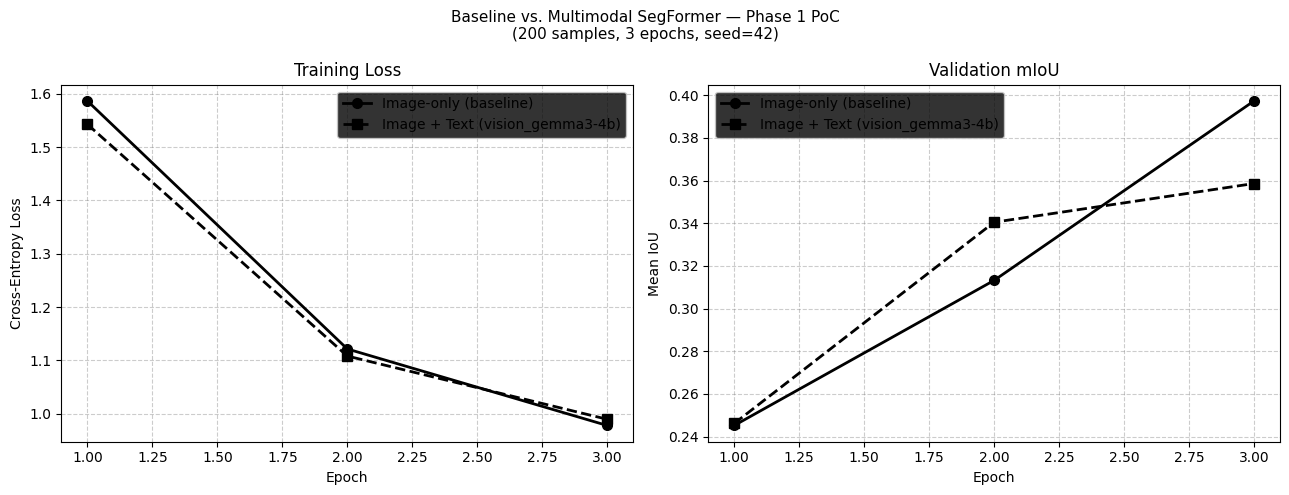


Model                                 Final Loss   Final Val mIoU
-----------------------------------------------------------------
Image-only (SegFormer baseline)           0.9780           0.3973
Image + Text (vision_gemma3-4b)           0.9896           0.3586

Δ Loss  (baseline − fused): -0.0117  ← baseline lower
Δ mIoU  (fused − baseline): -0.0387  ← baseline higher

Note: meaningful gains expected after full training on 8,000 samples in Phase 2.


In [25]:
epochs = list(range(1, CONFIG['num_epochs'] + 1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='white')

for ax in axes:
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.tick_params(colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')

# Training Loss
axes[0].plot(epochs, train_losses,       'o-',  color='black', lw=2, ms=7, label='Image-only (baseline)')
axes[0].plot(epochs, fused_train_losses, 's--', color='black', lw=2, ms=7, label=f'Image + Text ({CAPTION_COL})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Training Loss')
axes[0].legend(labelcolor='black')
axes[0].grid(True, linestyle='--', alpha=0.4, color='gray')

# Validation mIoU
axes[1].plot(epochs, val_mious,       'o-',  color='black', lw=2, ms=7, label='Image-only (baseline)')
axes[1].plot(epochs, fused_val_mious, 's--', color='black', lw=2, ms=7, label=f'Image + Text ({CAPTION_COL})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean IoU')
axes[1].set_title('Validation mIoU')
axes[1].legend(labelcolor='black')
axes[1].grid(True, linestyle='--', alpha=0.4, color='gray')

fig.suptitle(
    f'Baseline vs. Multimodal SegFormer — Phase 1 PoC\n'
    f'({CONFIG["subset_size"]} samples, {CONFIG["num_epochs"]} epochs, seed={CONFIG["seed"]})',
    fontsize=11, color='black'
)
plt.tight_layout()
plt.savefig('results/figures/baseline_vs_fused.png', dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()

# Summary table
print(f'\n{"Model":<35} {"Final Loss":>12} {"Final Val mIoU":>16}')
print('-' * 65)
print(f'{"Image-only (SegFormer baseline)":<35} {train_losses[-1]:>12.4f} {val_mious[-1]:>16.4f}')
print(f'{f"Image + Text ({CAPTION_COL})":<35} {fused_train_losses[-1]:>12.4f} {fused_val_mious[-1]:>16.4f}')

delta_loss = train_losses[-1] - fused_train_losses[-1]
delta_miou = fused_val_mious[-1] - val_mious[-1]
print(f'\nΔ Loss  (baseline − fused): {delta_loss:+.4f}  {"← fused lower ✓" if delta_loss > 0 else "← baseline lower"}')
print(f'Δ mIoU  (fused − baseline): {delta_miou:+.4f}  {"← fused higher ✓" if delta_miou > 0 else "← baseline higher"}')
print('\nNote: meaningful gains expected after full training on full data')


## Summary — Phase 1 Proof of Concept

Important Note: 3 epochs on 200 samples is a very short run. The fused model may not outperform
the baseline here — text conditioning typically needs more data and epochs to show its benefit.
The goal at this stage is to show the pipeline is correct and trainable, not to claim
state-of-the-art results. The full comparison happens in Phase 2 with 10,000 samples.


### Key Observations

- The mask conversion is the most error-prone step. I verified it visually by comparing the RGB mask
  to the class index mask for a real sample — the colors match the class table exactly.
- SegFormer MiT-B0 loads and fine-tunes correctly on the 7-class head. The loss decreases within
  the first epoch, which confirms the preprocessing pipeline is correct.
- BERT embeddings for the two caption sources (`vision_gemma3-4b` vs `vision_qwen3-vl-8b`) differ
  visibly in the CLS token space, which suggests they may contribute differently to the fused model.
  I will measure this difference quantitatively in Phase 2.
